In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt
import random


from torch import nn
from torchvision import transforms
from torchinfo import summary
from going_modular import data_setup, engine, predictions
from helper_functions import download_data, set_seeds, plot_loss_curves

device = "cuda" if torch.cuda.is_available() else "cpu"
device

c:\Users\abhit\OneDrive\Documents\Programming\neuron\GOD-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'cuda'

In [3]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [4]:
manual_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])


train_dataloader, test_dataloader, class_names = data_setup.create_dataloader(
    train_dir = train_dir,
    test_dir = test_dir,
    transform = manual_transform,
    batch_size = 32
)

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x2375dc30530>,
 ['pizza', 'steak', 'sushi'])

In [ ]:
image_btc, label_btc = next(iter(train_dataloader))

image, label = image_btc[0], label_btc[0]

image.shape, label

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

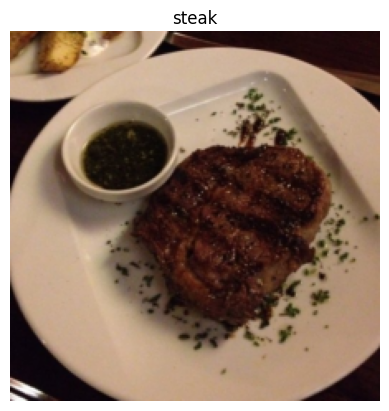

In [ ]:
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis(False)

In [ ]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels: int=3, patch_size: int=16, embedding_dim: int=768):
        super().__init__()

        self.patcher = nn.Conv2d(
            in_channels = in_channels,
            out_channels = embedding_dim,
            kernel_size = patch_size,
            stride = patch_size,
            padding = 0
        )

        self.flatten = nn.Flatten(
            start_dim = 2,
            end_dim = 3
        )

    def forward(self, x):
        image_resolution = x.shape[-1]
        assert image_resolution % patch_size == 0, f"Input image size must be divisible by patch size, image shape: {image_resolution}, patch size: {patch_size}"

        x_patched = self.patcher(x)
        x_flatten = self.flatten(x_patched)

        return x_flatten.permute(0, 2, 1)

In [ ]:
class MultiHeadAttentionLayer(nn.Module):
    def __init__(self, embedding_dim: int = 768, num_heads: int = 12, attn_dropout: float = 0):
        super().__init__()

        self.layer_norm = nn.LayerNorm(
            normalized_shape = embedding_dim
        )

        self.multi_head_attn = nn.MultiheadAttention(
            embed_dim = embedding_dim,
            num_heads = num_heads,
            dropout = attn_dropout,
            batch_first = True
        )

    def forward(self, x):
        x = self.layer_norm(x)
        attn_output, _ = self.multi_head_attn(
            query = x,
            key = x,
            value = x,
            need_weights = False
        )

        return attn_output

In [ ]:
class MLPBlock(nn.Module):
    def __init__(self, embedding_dim: int = 768, mlp_size: int = 3072, dropout: float = 0.1):
        super().__init__()

        self.layer_norm = nn.LayerNorm(
            normalized_shape = embedding_dim
        )

        self.mlp_block = nn.Sequential(
            nn.Linear(
                in_features = embedding_dim,
                out_features = mlp_size
            ),
            nn.GELU(),
            nn.Dropout(p = dropout),
            nn.Linear(
                in_features = mlp_size,
                out_features = embedding_dim
            ),
            nn.Dropout(p = dropout)
        )

    def forward(self, x):
        x = self.layer_norm(x)
        x = self.mlp_block(x)
        return x

In [ ]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embedding_dim: int=768, num_heads: int=12, mlp_size: int=3072, mlp_dropout: float=0.1, attn_dropout: float=0):
        super().__init__()

        self.msa_block = MultiHeadAttentionLayer(
            embedding_dim = embedding_dim,
            num_heads = num_heads,
            attn_dropout = attn_dropout
        )

        self.mlp_block = MLPBlock(
            embedding_dim = embedding_dim,
            mlp_size = mlp_size,
            dropout = mlp_dropout
        )

    def forward(self, x):
        x = self.msa_block(x) + x
        x = self.mlp_block(x) + x
        return x

In [ ]:
torch_transformer_layer = nn.TransformerEncoderLayer(
    d_model = 768,
    nhead = 12,
    dim_feedforward = 3072,
    dropout = 0.1,
    activation = "gelu",
    batch_first = True,
    norm_first = True
)


summary(model=torch_transformer_layer,
         input_size=(1, 197, 768), # (batch_size, num_patches, embedding_dimension)
         col_names=["input_size", "output_size", "num_params", "trainable"],
         col_width=20,
         row_settings=["var_names"])

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
TransformerEncoderLayer (TransformerEncoderLayer)  [1, 197, 768]        [1, 197, 768]        --                   True
├─LayerNorm (norm1)                                [1, 197, 768]        [1, 197, 768]        1,536                True
├─MultiheadAttention (self_attn)                   [1, 197, 768]        [1, 197, 768]        2,362,368            True
├─Dropout (dropout1)                               [1, 197, 768]        [1, 197, 768]        --                   --
├─LayerNorm (norm2)                                [1, 197, 768]        [1, 197, 768]        1,536                True
├─Linear (linear1)                                 [1, 197, 768]        [1, 197, 3072]       2,362,368            True
├─Dropout (dropout)                                [1, 197, 3072]       [1, 197, 3072]       --                   --
├─Linear (linear2)                             

In [ ]:
class ViT(nn.Module):

    def __init__(self, img_size: int=224, in_channels: int=3, patch_size: int=16, num_transformer_layer: int=12, embedding_dim: int=768, mlp_size: int=3072, num_heads: int=12, attn_dropout: float=0, mlp_dropout: float=0.1, embedding_dropout: float=0.1, num_classes: int=1000 ):

        super().__init__()

        assert img_size % patch_size == 0, f"Image should be divisible by {patch_size}"

        self.num_patches = (img_size * img_size) // (patch_size**2)

        self.class_embedding = nn.Parameter(
            data = torch.randn(
                1,
                1,
                embedding_dim
            ),
            requires_grad = True
        )

        self.position_embedding = nn.Parameter(
            data = torch.randn(
                1,
                1,
                embedding_dim
            ),
            requires_grad = True
        )

        self.embedding_dropout = nn.Dropout(
            p = embedding_dropout
        )

        self.patch_embedding = PatchEmbedding(
            in_channels = in_channels,
            patch_size = patch_size,
            embedding_dim = embedding_dim
        )

        self.transformer_encoder = nn.Sequential(
            *[
                TransformerEncoderBlock(
                    embedding_dim = embedding_dim,
                    num_heads = num_heads,
                    mlp_size = mlp_size,
                    mlp_dropout = mlp_dropout
                ) for _ in range(num_transformer_layer)
            ]
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(
                normalized_shape = embedding_dim
            ),
            nn.Linear(
                in_features = embedding_dim,
                out_features = num_classes
            )
        )

    def forward(self, x):

        batch_size = x.shape[0]

        class_token = self.class_embedding.expand(batch_size, -1, -1)

        x = self.patch_embedding(x)

        x = torch.cat(
            (
                class_token,
                x
            ),
            dim = 1
        )

        x = self.position_embedding + x

        x = self.embedding_dropout(x)

        x = self.transformer_encoder(x)

        x = self.classifier(x[:, 0])

        return x

In [ ]:
optimizer = torch.optim.Adam(
    params = vit.parameters(),
    lr = 3e-3,
    betas = (0.9, 0.999),
    weight_decay = 0.3
)

loss_fn = nn.CrossEntropyLoss()

set_seeds()

result = engine.train(
    model = vit,
    train_dataloader = train_dataloader,
    test_dataloader = test_dataloader,
    loss_fn = loss_fn,
    optimizer = optimizer,
    epochs = 10,
    device = device,
    writer = None
)

 10%|█         | 1/10 [01:37<14:38, 97.61s/it]

Epoch : 1 |train loss : 4.5309 |train acc : 0.2500 |test loss : 1.0046 |test acc : 0.5417


 20%|██        | 2/10 [02:58<11:43, 87.96s/it]

Epoch : 2 |train loss : 1.5776 |train acc : 0.2969 |test loss : 2.4290 |test acc : 0.2604


 30%|███       | 3/10 [04:23<10:05, 86.51s/it]

...

Epoch : 8 |train loss : 1.1559 |train acc : 0.4375 |test loss : 1.3785 |test acc : 0.2604


 90%|█████████ | 9/10 [12:52<01:24, 84.90s/it]

Epoch : 9 |train loss : 1.1541 |train acc : 0.4375 |test loss : 1.0152 |test acc : 0.5417


100%|██████████| 10/10 [14:17<00:00, 85.78s/it]

Epoch : 10 |train loss : 1.2281 |train acc : 0.2383 |test loss : 1.4026 |test acc : 0.2604


In [ ]:
plot_loss_curves(result)

In [ ]:
pretrained_vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT

pretrained_vit = torchvision.models.vit_b_16(weights = pretrained_vit_weights).to(device)

for params in pretrained_vit.parameters():
    params.requires_grad = False

set_seeds()

pretrained_vit.heads = nn.Linear(
    in_features = 768,
    out_features = len(class_names)
).to(device)

pretrained_vit

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [ ]:
summary(model=pretrained_vit,
         input_size=(32, 3, 224, 224), # (batch_size, color_channels, height, width)
         # col_names=["input_size"], # uncomment for smaller output
         col_names=["input_size", "output_size", "num_params", "trainable"],
         col_width=20,
         row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [32, 3, 224, 224]    [32, 3]              768                  Partial
├─Conv2d (conv_proj)                                         [32, 3, 224, 224]    [32, 768, 14, 14]    (590,592)            False
├─Encoder (encoder)                                          [32, 197, 768]       [32, 197, 768]       151,296              False
│    └─Dropout (dropout)                                     [32, 197, 768]       [32, 197, 768]       --                   --
│    └─Sequential (layers)                                   [32, 197, 768]       [32, 197, 768]       --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [32, 197, 768]       [32, 197, 768]       (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [32, 197, 768]       [32, 

In [ ]:
pretrained_vit_transform = pretrained_vit_weights.transforms()
pretrained_vit_transform

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [ ]:
train_dataloader_pretrained, test_dataloader_pretrained, class_names = data_setup.create_dataloader(
    train_dir = train_dir,
    test_dir = test_dir,
    transform = pretrained_vit_transform,
    batch_size = 32
)

In [ ]:
set_seeds()

optimizer = torch.optim.Adam(
    params = pretrained_vit.parameters(),
    lr = 1e-3
)

loss_fn = nn.CrossEntropyLoss()

results_pretrained = engine.train(
    model = pretrained_vit,
    train_dataloader = train_dataloader_pretrained,
    test_dataloader = test_dataloader_pretrained,
    optimizer = optimizer,
    loss_fn = loss_fn,
    epochs = 10,
    device = device,
    writer  = None
)

  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:29<04:24, 29.38s/it]

Epoch : 1 |train loss : 0.7663 |train acc : 0.7188 |test loss : 0.5435 |test acc : 0.8769


 20%|██        | 2/10 [01:09<04:43, 35.47s/it]

Epoch : 2 |train loss : 0.3436 |train acc : 0.9453 |test loss : 0.3257 |test acc : 0.8977


...

Epoch : 8 |train loss : 0.0793 |train acc : 0.9844 |test loss : 0.2268 |test acc : 0.9081


 90%|█████████ | 9/10 [04:55<00:32, 32.56s/it]

Epoch : 9 |train loss : 0.1084 |train acc : 0.9883 |test loss : 0.2064 |test acc : 0.9384


100%|██████████| 10/10 [05:28<00:00, 32.82s/it]

Epoch : 10 |train loss : 0.0646 |train acc : 0.9922 |test loss : 0.1795 |test acc : 0.9176


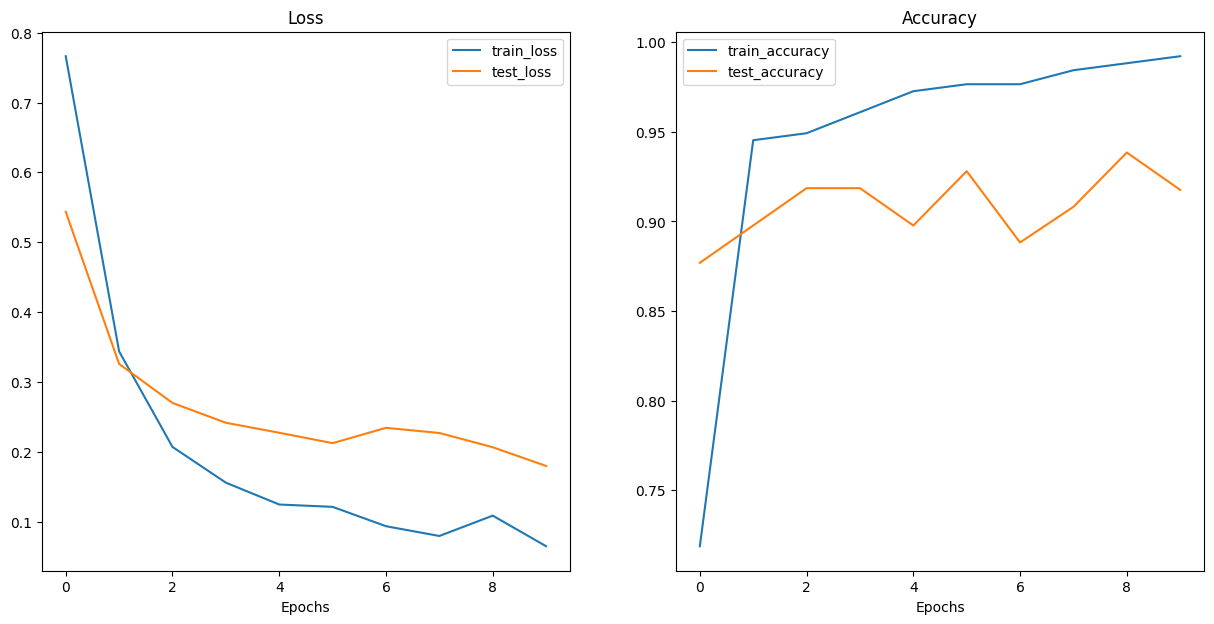

In [ ]:
plot_loss_curves(results_pretrained)

In [ ]:
from going_modular import utils

utils.save_model(
    model = pretrained_vit,
    target_dir = "models",
    model_name = "08_pretrained_vit_feature_extractor_pizza_steak_sushi.pth"
)



[INFO] saving model to models\08_pretrained_vit_feature_extractor_pizza_steak_sushi.pth


In [ ]:
from pathlib import Path

pretrained_vit_model_size = Path("models/08_pretrained_vit_feature_extractor_pizza_steak_sushi.pth").stat().st_size // (1024*1024) 
print(f"Pretrained ViT feature extractor model size: {pretrained_vit_model_size} MB")

Pretrained ViT feature extractor model size: 327 MB


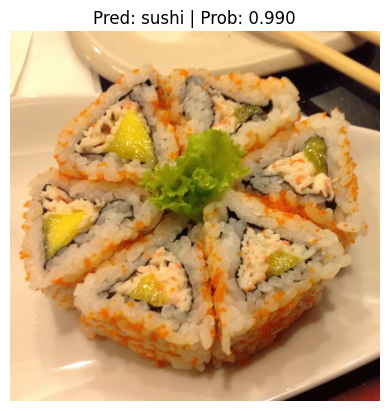

In [ ]:
import requests

from going_modular.predictions import pred_and_plot_image

data_path = Path("data/")

custom_image_path = data_path / "3837522.jpg"

pred_and_plot_image(model=pretrained_vit,
                    image_path=custom_image_path,
                    class_names=class_names)